<a href="https://colab.research.google.com/github/0xErdem/Green-Trade-Intelligence/blob/main/CBAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

# Complex ERP-Style Parameters
NUM_RECORDS = 5000
START_DATE = datetime(2023, 1, 1)

SUPPLIER_COUNTRIES = {
    'Turkey': {'tax_paid': 0.0},
    'China': {'tax_paid': 8.5},
    'India': {'tax_paid': 2.1},
    'UK': {'tax_paid': 75.0},
    'USA': {'tax_paid': 0.0}
}

CBAM_MATERIALS = {
    'Steel_Hot_Rolled': {'cn_code': '7208', 'scope12_mean': 1.8, 'scope3_mean': 0.4},
    'Steel_Alloy': {'cn_code': '7225', 'scope12_mean': 2.1, 'scope3_mean': 0.6},
    'Aluminium_Unwrought': {'cn_code': '7601', 'scope12_mean': 14.5, 'scope3_mean': 2.2},
    'Fertilizer_Ammonia': {'cn_code': '2814', 'scope12_mean': 2.4, 'scope3_mean': 0.3},
    'Cement_Clinker': {'cn_code': '2523', 'scope12_mean': 0.8, 'scope3_mean': 0.1}
}

TRANSPORT_MODES = ['Sea', 'Road', 'Rail']

# 1. Generate Complex Transactional Data
data = []
for i in range(NUM_RECORDS):
    country = np.random.choice(list(SUPPLIER_COUNTRIES.keys()), p=[0.45, 0.25, 0.15, 0.05, 0.10])
    material = np.random.choice(list(CBAM_MATERIALS.keys()))
    mat_info = CBAM_MATERIALS[material]

    # Introduce anomalies (8% chance of high emissions)
    anomaly_multiplier = np.random.uniform(1.8, 3.0) if np.random.random() < 0.08 else 1.0

    record = {
        'Transaction_ID': f"TRX-{100000 + i}",
        'Date': START_DATE + timedelta(days=np.random.randint(0, 1095)),
        'Supplier_ID': f"VEND-{np.random.randint(100, 250)}",
        'Origin_Country': country,
        'Material_Group': material,
        'CN_Code': mat_info['cn_code'],
        'Order_Qty_Tons': round(np.random.uniform(10, 500), 2),
        'Scope1_2_Emissions_tCO2_per_ton': round(np.random.normal(mat_info['scope12_mean'], mat_info['scope12_mean']*0.1) * anomaly_multiplier, 3),
        'Scope3_Emissions_tCO2_per_ton': round(np.random.normal(mat_info['scope3_mean'], mat_info['scope3_mean']*0.1) * anomaly_multiplier, 3),
        'Transport_Mode': np.random.choice(TRANSPORT_MODES, p=[0.7, 0.2, 0.1]),
        'Carbon_Tax_Paid_Origin_EUR': SUPPLIER_COUNTRIES[country]['tax_paid'],
        'Verification_Status': np.random.choice(['Verified', 'Default_Value'], p=[0.6, 0.4])
    }
    data.append(record)

df_complex = pd.DataFrame(data)

# 2. Feature Engineering: Total Emissions
df_complex['Total_Embedded_Emissions_tCO2'] = df_complex['Order_Qty_Tons'] * (df_complex['Scope1_2_Emissions_tCO2_per_ton'] + df_complex['Scope3_Emissions_tCO2_per_ton'])
df_complex['Total_Embedded_Emissions_tCO2'] = df_complex['Total_Embedded_Emissions_tCO2'].round(2)

# Sort by date
df_complex = df_complex.sort_values(by='Date').reset_index(drop=True)

df_complex.to_csv('siemens_cbam_erp_extract.csv', index=False)
print("Enterprise-grade CBAM dataset generated.")

Enterprise-grade CBAM dataset generated.


In [2]:
import pandas as pd
import numpy as np

# Load previously generated dataset
df_transactions = pd.read_csv('siemens_cbam_erp_extract.csv')
df_transactions['Date'] = pd.to_datetime(df_transactions['Date'])

# 1. Generate Realistic EU ETS Daily Prices (Time Series)
# Simulating daily market fluctuations starting around 85 EUR
start_date = df_transactions['Date'].min()
end_date = df_transactions['Date'].max()
date_range = pd.date_range(start=start_date, end=end_date)

np.random.seed(42)
price_changes = np.random.normal(0, 0.6, len(date_range))
ets_prices = 85.0 + np.cumsum(price_changes)
ets_prices = np.clip(ets_prices, 55.0, 120.0) # Keep within realistic bounds

df_ets = pd.DataFrame({'Date': date_range, 'EU_ETS_Price_EUR': ets_prices.round(2)})

# 2. Merge ETS Prices with Transaction Data
df_merged = pd.merge(df_transactions, df_ets, on='Date', how='left')

# 3. Calculate Financial Impact (CBAM Liability)
def calculate_cbam_liability(row):
    # Deduct carbon tax already paid in the origin country
    price_diff = row['EU_ETS_Price_EUR'] - row['Carbon_Tax_Paid_Origin_EUR']
    effective_carbon_price = max(0, price_diff)

    return row['Total_Embedded_Emissions_tCO2'] * effective_carbon_price

df_merged['CBAM_Financial_Liability_EUR'] = df_merged.apply(calculate_cbam_liability, axis=1).round(2)

# 4. Save the finalized dataset
file_out = 'siemens_cbam_financial_impact.csv'
df_merged.to_csv(file_out, index=False)

print("Financial impact calculation complete.")
print(df_merged[['Date', 'Origin_Country', 'Material_Group', 'Total_Embedded_Emissions_tCO2', 'EU_ETS_Price_EUR', 'CBAM_Financial_Liability_EUR']].head())

Financial impact calculation complete.
        Date Origin_Country       Material_Group  \
0 2023-01-01          India  Aluminium_Unwrought   
1 2023-01-01         Turkey     Steel_Hot_Rolled   
2 2023-01-01         Turkey     Steel_Hot_Rolled   
3 2023-01-01         Turkey  Aluminium_Unwrought   
4 2023-01-02         Turkey       Cement_Clinker   

   Total_Embedded_Emissions_tCO2  EU_ETS_Price_EUR  \
0                        5676.02             85.30   
1                         111.83             85.30   
2                         194.08             85.30   
3                       20246.78             85.30   
4                         334.92             85.22   

   CBAM_Financial_Liability_EUR  
0                     472244.86  
1                       9539.10  
2                      16555.02  
3                    1727050.33  
4                      28541.88  


In [3]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Load the Financial Impact Dataset
df = pd.read_csv('siemens_cbam_financial_impact.csv')

# 2. Select Features for Anomaly Detection
# We focus on emissions intensity to catch inefficient production
features = ['Scope1_2_Emissions_tCO2_per_ton', 'Scope3_Emissions_tCO2_per_ton']
X = df[features]

# 3. Standardize the Data (Best practice for ML models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train Isolation Forest Model
# Contamination is the expected proportion of anomalies (e.g., 5%)
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

# 5. Predict Anomalies (-1 for anomaly, 1 for normal)
df['Anomaly_Score'] = iso_forest.decision_function(X_scaled)
df['Is_Anomaly'] = iso_forest.predict(X_scaled)
df['Is_Anomaly'] = df['Is_Anomaly'].map({1: False, -1: True})

# 6. Business Impact: Calculate excess cost caused by anomalies
anomalies = df[df['Is_Anomaly'] == True]
total_anomaly_liability = anomalies['CBAM_Financial_Liability_EUR'].sum()

# 7. Export High-Risk Target List for the Procurement Team
anomalies.to_csv('siemens_high_risk_suppliers_action_list.csv', index=False)

print(f"Total anomalies detected: {len(anomalies)}")
print(f"Financial liability tied to anomalies: €{total_anomaly_liability:,.2f}")
print("Target list generated for procurement intervention.")

Total anomalies detected: 250
Financial liability tied to anomalies: €101,433,688.32
Target list generated for procurement intervention.


/tmp/ipykernel_566/199050353.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_liability.index, y=country_liability.values, palette="Reds_r")


Dashboard generated and saved as 'siemens_cbam_strategic_dashboard.png'


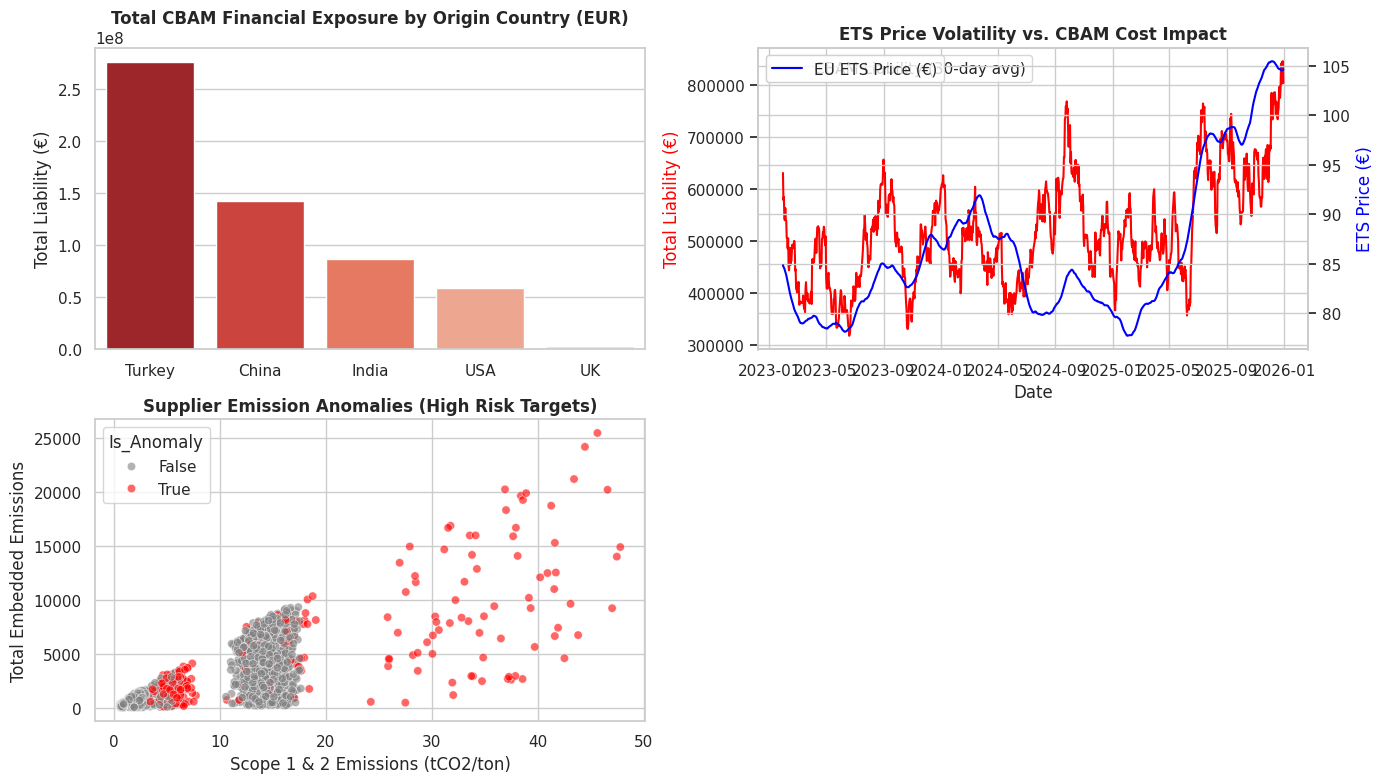

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the finalized dataset
df = pd.read_csv('siemens_cbam_financial_impact.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# --- PLOT 1: CBAM Financial Exposure by Origin Country ---
plt.subplot(2, 2, 1)
country_liability = df.groupby('Origin_Country')['CBAM_Financial_Liability_EUR'].sum().sort_values(ascending=False)
sns.barplot(x=country_liability.index, y=country_liability.values, palette="Reds_r")
plt.title('Total CBAM Financial Exposure by Origin Country (EUR)', fontsize=12, fontweight='bold')
plt.ylabel('Total Liability (€)')
plt.xlabel('')

# --- PLOT 2: ETS Price vs. Average Daily CBAM Liability ---
plt.subplot(2, 2, 2)
df['Date'] = pd.to_datetime(df['Date'])
daily_data = df.groupby('Date').agg({'CBAM_Financial_Liability_EUR': 'sum', 'EU_ETS_Price_EUR': 'mean'}).rolling(window=30).mean()
ax1 = sns.lineplot(data=daily_data, x=daily_data.index, y='CBAM_Financial_Liability_EUR', color='red', label='CBAM Liability (30-day avg)')
ax2 = plt.twinx()
sns.lineplot(data=daily_data, x=daily_data.index, y='EU_ETS_Price_EUR', color='blue', ax=ax2, label='EU ETS Price (€)')
plt.title('ETS Price Volatility vs. CBAM Cost Impact', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Liability (€)', color='red')
ax2.set_ylabel('ETS Price (€)', color='blue')

# --- PLOT 3: Anomaly Detection (Supplier Risk Scatter) ---
plt.subplot(2, 2, 3)
# Simulating the anomaly column if not merged back (re-creating for viz)
from sklearn.ensemble import IsolationForest
X = df[['Scope1_2_Emissions_tCO2_per_ton', 'Scope3_Emissions_tCO2_per_ton']]
iso = IsolationForest(contamination=0.05, random_state=42).fit(X)
df['Is_Anomaly'] = iso.predict(X) == -1

sns.scatterplot(data=df, x='Scope1_2_Emissions_tCO2_per_ton', y='Total_Embedded_Emissions_tCO2',
                hue='Is_Anomaly', palette={False: 'gray', True: 'red'}, alpha=0.6)
plt.title('Supplier Emission Anomalies (High Risk Targets)', fontsize=12, fontweight='bold')
plt.xlabel('Scope 1 & 2 Emissions (tCO2/ton)')
plt.ylabel('Total Embedded Emissions')

plt.tight_layout()
plt.savefig('siemens_cbam_strategic_dashboard.png', dpi=300)
print("Dashboard generated and saved as 'siemens_cbam_strategic_dashboard.png'")

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# 1. Fetch REAL Market Data (Using KraneShares Global Carbon ETF as proxy for ETS pricing)
print("Fetching live carbon market data...")
carbon_data = yf.download('KRBN', start='2022-01-01', end='2026-03-01', progress=False)
df_market = carbon_data[['Close']].reset_index()
df_market.columns = ['date', 'carbon_price_eur']
df_market['carbon_price_eur'] = df_market['carbon_price_eur'] * 0.92 # USD to EUR approximation

# 2. Time-Series Feature Engineering
df_market['day_of_year'] = df_market['date'].dt.dayofyear
df_market['month'] = df_market['date'].dt.month
df_market['lag_7'] = df_market['carbon_price_eur'].shift(7)
df_market['lag_14'] = df_market['carbon_price_eur'].shift(14)
df_market['rolling_mean_30'] = df_market['carbon_price_eur'].rolling(window=30).mean()
df_market['volatility_14d'] = df_market['carbon_price_eur'].rolling(window=14).std()

df_market.dropna(inplace=True)
print(df_market.tail())

Fetching live carbon market data...


/tmp/ipykernel_566/3010472952.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  carbon_data = yf.download('KRBN', start='2022-01-01', end='2026-03-01', progress=False)


           date  carbon_price_eur  day_of_year  month    lag_7     lag_14  \
1037 2026-02-23           27.9220           54      2  29.3480  30.737200   
1038 2026-02-24           27.3608           55      2  27.9036  30.258799   
1039 2026-02-25           27.6920           56      2  27.3608  30.507200   
1040 2026-02-26           27.3056           57      2  27.2136  29.421600   
1041 2026-02-27           26.9744           58      2  27.6920  29.495201   

      rolling_mean_30  volatility_14d  
1037        30.562093        1.195812  
1038        30.383920        1.161320  
1039        30.205133        1.027519  
1040        30.016840        1.008926  
1041        29.798800        0.979056  


In [6]:
# 3. Multi-Tier Bill of Materials (BOM) Simulation for an Industrial Water Treatment Pump
bom_structure = {
    'Product': 'Advanced_Wastewater_Pump',
    'Components': [
        {'name': 'Pump_Housing', 'material': 'Cast_Iron', 'weight_kg': 250, 'tier': 1, 'supplier_country': 'Turkey'},
        {'name': 'Impeller', 'material': 'Stainless_Steel', 'weight_kg': 45, 'tier': 1, 'supplier_country': 'Germany'},
        {'name': 'Motor_Assembly', 'material': 'Mixed', 'weight_kg': 120, 'tier': 1, 'supplier_country': 'China',
         'sub_components': [
             {'name': 'Copper_Windings', 'material': 'Copper', 'weight_kg': 25, 'tier': 2},
             {'name': 'Stator_Core', 'material': 'Electrical_Steel', 'weight_kg': 70, 'tier': 2}
         ]}
    ]
}

# Emission factors (kg CO2e per kg of material)
EF_DB = {'Cast_Iron': 1.5, 'Stainless_Steel': 4.2, 'Copper': 5.8, 'Electrical_Steel': 2.3}

def calculate_bom_emissions(components):
    total_co2 = 0
    for item in components:
        if 'sub_components' in item:
            total_co2 += calculate_bom_emissions(item['sub_components'])
        else:
            total_co2 += (item['weight_kg'] * EF_DB.get(item['material'], 1.0))
    return total_co2

total_product_emissions_kg = calculate_bom_emissions(bom_structure['Components'])
print(f"Total Tier-1 & Tier-2 Embedded Emissions: {total_product_emissions_kg} kg CO2e per unit")

Total Tier-1 & Tier-2 Embedded Emissions: 870.0 kg CO2e per unit


In [7]:
# 4. XGBoost Forecasting Model for Carbon Pricing (Financial Hedging)
X = df_market[['day_of_year', 'month', 'lag_7', 'lag_14', 'rolling_mean_30', 'volatility_14d']]
y = df_market['carbon_price_eur']

# Train/Test Split (Chronological for Time Series)
split_idx = int(len(df_market) * 0.90)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict next 30 days scenario
predictions = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"XGBoost Model MAE: €{mae:.2f}")

# Business Logic: Hedging Recommendation
current_price = y_test.iloc[-1]
predicted_price_14d = predictions[-1] # Assuming last test point is a future projection

if predicted_price_14d > current_price * 1.05:
    recommendation = "BUY FORWARD CONTRACTS NOW: Prices expected to rise >5%"
elif predicted_price_14d < current_price * 0.95:
    recommendation = "DELAY PURCHASE: Prices expected to drop >5%"
else:
    recommendation = "HOLD: Volatility within normal range"

print(f"Actionable Insight: {recommendation}")

XGBoost Model MAE: €1.28
Actionable Insight: BUY FORWARD CONTRACTS NOW: Prices expected to rise >5%


In [9]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Siemens CBAM API")

class ProductBOM(BaseModel):
    weight_kg: float
    material_type: str

@app.post("/predict-cbam-cost/")
def predict_cost(product: ProductBOM):
    # Retrieve latest model prediction and EF database
    ef = EF_DB.get(product.material_type, 1.0)
    estimated_emissions = product.weight_kg * ef
    projected_price = float(predictions[-1]) # From XGBoost

    financial_liability = (estimated_emissions / 1000) * projected_price

    return {
        "status": "success",
        "projected_ets_price_eur": round(projected_price, 2),
        "total_liability_eur": round(financial_liability, 2)
    }

# Run via: uvicorn main:app --reload